<a href="https://colab.research.google.com/github/weee-is-nerd/Bristol_population_prediction/blob/main/BatchNormalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Batch Normalization for Grocery Image Classification

This notebook is for my Advanced Machine Learning project. The aim is to compare a normal CNN model with another CNN model that uses Batch Normalization. A small grocery image dataset with four classes


1.   apple
2.   banana


1.   potato
2.   watermelon

The main experiment is not only about final accuracy. This follows teh idea from the Batch Normalization paper and also connects to the project extension, where batch sizes of 32, 16, and 8 are tested.




# Importing Libraries

In this section, the libraries needed for image loading, CNN model building, plotting graphs, and evaluating the model are imported. TensorFlow is used for the CNN implementation, while Matplotlib and Seaborn are used for visualising the results.

In [2]:
# Batch Normalization vs No BatchNorm
# Dataset: apple, banana, potato, watermelon

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, ReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Experiment Settings

Here I define the main settings used throughout the notebook. I use a fixed random seed to make the results more consistent between runs, although deep learning results may still change slightly because of GPU operations, Dropout, and Batch Normalization behaviour.

The images are resized to **128 × 128 pixels**, and the experiments are repeated with batch sizes **32, 16, and 8**.


In [3]:
# Basic settings used for the experiments

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_HEIGHT = 128
IMG_WIDTH = 128
EPOCHS = 15
BATCH_SIZES = [32, 16, 8]

base_path = "/content/dataset"
train_path = "/content/dataset/train"
validation_path = "/content/dataset/validation"
test_path = "/content/dataset/test"

class_names = ["apple", "banana", "potato", "watermelon"]

# Checking the Dataset

Before training, I check whether the dataset folders contain images. My dataset is organised into `train`, `validation`, and `test` folders. Each folder should contain the same four class folders: apple, banana, potato, and watermelon.

This step is useful because TensorFlow will not train properly if the images are not directly inside the correct class folders.


In [4]:
# Quick check to make sure the dataset folders contain images

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")
    split_path = os.path.join(base_path, split)

    for class_name in class_names:
        class_path = os.path.join(split_path, class_name)

        if os.path.exists(class_path):
            images = os.listdir(class_path)
            print(f"{class_name}: {len(images)} images")
        else:
            print(f"{class_name}: folder missing")



TRAIN
apple: 68 images
banana: 75 images
potato: 77 images
watermelon: 84 images

VALIDATION
apple: 10 images
banana: 9 images
potato: 10 images
watermelon: 11 images

TEST
apple: 10 images
banana: 9 images
potato: 10 images
watermelon: 10 images


# Loading and Preprocessing the Images

This function loads the images using `ImageDataGenerator`. I use `rescale=1./255` so that pixel values are normalised between 0 and 1. This makes the input values easier for the CNN to learn from.

The function returns three datasets: training data, validation data, and test data. The training data is shuffled, but validation and test data are not shuffled because they are used for evaluation.

In [5]:
# Function to load images from train, test, validation folders

def create_data_generators(batch_size):
    datagen = ImageDataGenerator(rescale=1./255)

    train_data = datagen.flow_from_directory(
        train_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        class_mode="categorical",
        classes=class_names,
        shuffle=True,
        seed=SEED
    )

    validation_data = datagen.flow_from_directory(
        validation_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        class_mode="categorical",
        classes=class_names,
        shuffle=False,
        seed=SEED
    )

    test_data = datagen.flow_from_directory(
        test_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        class_mode="categorical",
        classes=class_names,
        shuffle=False,
        seed=SEED
    )

    return train_data, validation_data, test_data

# Baseline CNN Without Batch Normalization

This is the baseline model. It uses two convolutional layers with ReLU activations and max-pooling layers. After that, the feature maps are flattened and passed into a dense layer. I also use Dropout to reduce overfitting.

This model does not include Batch Normalization, so it acts as the control model for comparison.

In [6]:
# Baseline CNN model without Batch Normalization

def build_cnn_without_bn(num_classes):
    model = Sequential()

    model.add(tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

    model.add(Conv2D(32, (3, 3)))
    model.add(ReLU())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3)))
    model.add(ReLU())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(128))
    model.add(ReLU())
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# CNN With Batch Normalization

This model uses the same overall architecture as the baseline CNN, but Batch Normalization layers are added after the convolutional layers and the dense layer. I kept the architecture mostly the same so that the comparison is fair.

The purpose of this model is to see whether Batch Normalization improves training stability, convergence speed, and final classification performance.


In [7]:
# CNN model with Batch Normalization layers

def build_cnn_with_bn(num_classes):
    model = Sequential()

    model.add(tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

    model.add(Conv2D(32, (3, 3)))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3)))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Running the Experiments

In this section, both models are trained using batch sizes 32, 16, and 8. For each batch size, the notebook trains:

- CNN without Batch Normalization
- CNN with Batch Normalization

The validation and test results are stored in a results table so the models can be compared side by side later.

In [8]:
# Run the BN vs no BN experiments for each batch size

results = []
histories = {}

for batch_size in BATCH_SIZES:

    print("\n===================================")
    print(f"Batch size: {batch_size}")
    print("===================================")

    train_data, validation_data, test_data = create_data_generators(batch_size)
    num_classes = train_data.num_classes

    # CNN without BN
    print("\nTraining CNN without Batch Normalization")

    model_without_bn = build_cnn_without_bn(num_classes)

    history_without_bn = model_without_bn.fit(
        train_data,
        validation_data=validation_data,
        epochs=EPOCHS
    )

    val_loss_no_bn, val_acc_no_bn = model_without_bn.evaluate(validation_data)
    test_loss_no_bn, test_acc_no_bn = model_without_bn.evaluate(test_data)

    results.append({
        "Model": "CNN without BatchNorm",
        "Batch Size": batch_size,
        "Validation Accuracy": val_acc_no_bn,
        "Validation Loss": val_loss_no_bn,
        "Test Accuracy": test_acc_no_bn,
        "Test Loss": test_loss_no_bn
    })

    histories[f"No BN - Batch {batch_size}"] = history_without_bn

    # CNN with BN
    print("\nTraining CNN with Batch Normalization")

    model_with_bn = build_cnn_with_bn(num_classes)

    history_with_bn = model_with_bn.fit(
        train_data,
        validation_data=validation_data,
        epochs=EPOCHS
    )

    val_loss_bn, val_acc_bn = model_with_bn.evaluate(validation_data)
    test_loss_bn, test_acc_bn = model_with_bn.evaluate(test_data)

    results.append({
        "Model": "CNN with BatchNorm",
        "Batch Size": batch_size,
        "Validation Accuracy": val_acc_bn,
        "Validation Loss": val_loss_bn,
        "Test Accuracy": test_acc_bn,
        "Test Loss": test_loss_bn
    })

    histories[f"With BN - Batch {batch_size}"] = history_with_bn


Batch size: 32
Found 304 images belonging to 4 classes.
Found 39 images belonging to 4 classes.
Found 39 images belonging to 4 classes.

Training CNN without Batch Normalization
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.3651 - loss: 1.4537 - val_accuracy: 0.5385 - val_loss: 1.0068
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6118 - loss: 0.8987 - val_accuracy: 0.7949 - val_loss: 0.5847
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7105 - loss: 0.7317 - val_accuracy: 0.7692 - val_loss: 0.5669
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7763 - loss: 0.6684 - val_accuracy: 0.6154 - val_loss: 0.6611
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7862 - loss: 0.5395 - val_accuracy: 0.7949 - val_loss: 0.4443
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8026 - loss: 0.4815 - val_accuracy: 0.7949 - val_loss: 0.5479
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8750 - loss: 0.3993 - val_accuracy: 0.8974 - val_loss: 0.4186
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9375 - loss: 0.2349 - val_accuracy: 0.8462 - val_loss: 0.3753
Epo

# Results Table

This table summarises the validation and test results for all experiments. It is useful for comparing the CNN with Batch Normalization against the CNN without Batch Normalization for each batch size.

In [9]:
results_df = pd.DataFrame(results)
display(results_df)


,Model,Batch Size,Validation Accuracy,Validation Loss,Test Accuracy,Test Loss
0,CNN without BatchNorm,32,0.897436,0.373337,0.897436,0.373337
1,CNN with BatchNorm,32,0.307692,1.906287,0.307692,1.906053
2,CNN without BatchNorm,16,0.948718,0.218622,0.948718,0.218617
3,CNN with BatchNorm,16,0.564103,0.903657,0.564103,0.902957
4,CNN without BatchNorm,8,0.871795,0.449969,0.871795,0.449969
5,CNN with BatchNorm,8,0.871795,0.356489,0.871795,0.356380


# Accuracy Curves

The accuracy graph shows how training accuracy and validation accuracy change across epochs. This helps me compare how quickly each model learns and whether Batch Normalization makes the training process more stable.

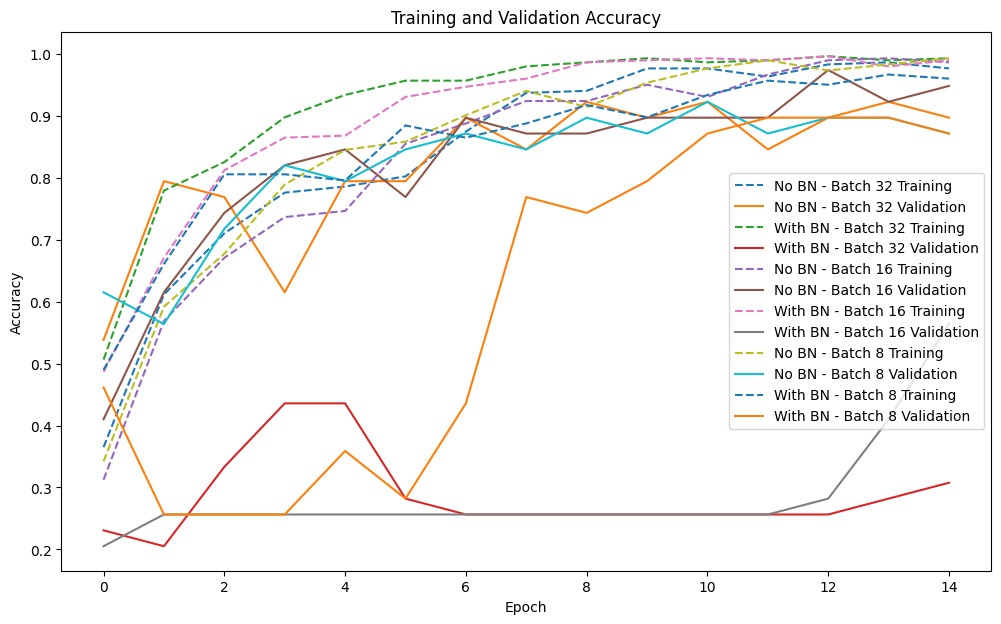

In [10]:
# ACCURACY GRAPH

plt.figure(figsize=(12, 7))

for name, history in histories.items():
    plt.plot(history.history["accuracy"], linestyle="--", label=f"{name} Training")
    plt.plot(history.history["val_accuracy"], label=f"{name} Validation")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Curves

The loss graph shows how training loss and validation loss change during training. This is important because my project is not only about final accuracy. I also want to compare convergence behaviour and training stability.

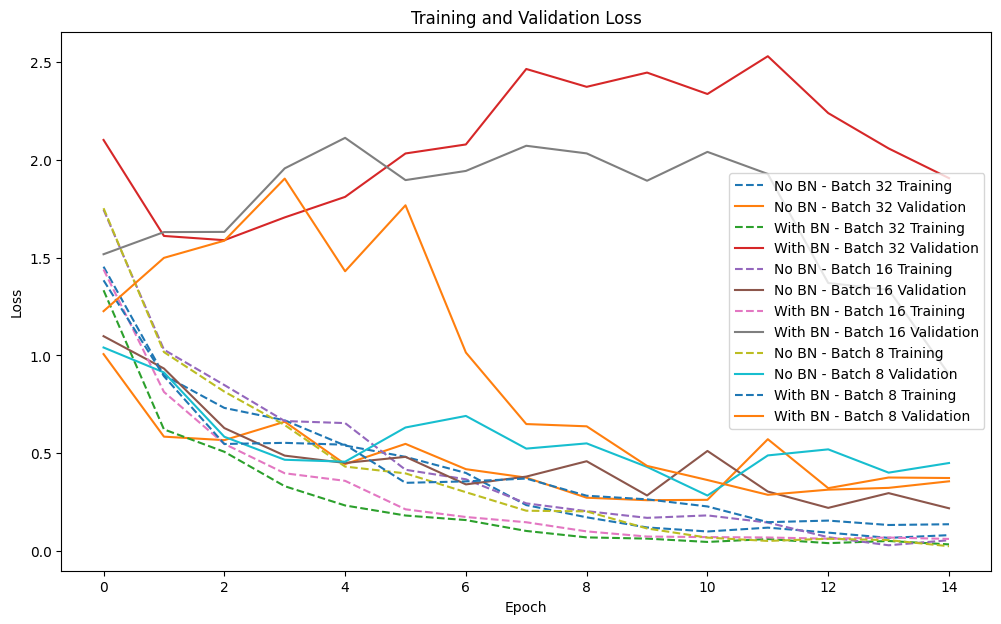

In [11]:
# LOSS GRAPH

plt.figure(figsize=(12, 7))

for name, history in histories.items():
    plt.plot(history.history["loss"], linestyle="--", label=f"{name} Training")
    plt.plot(history.history["val_loss"], label=f"{name} Validation")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Selecting the Best Model

After comparing all experiments, I select the best model based on validation accuracy. I then retrain that model using the same settings and evaluate it on the test set. The test set is only used at the end so that the final evaluation is more reliable.

In [12]:
# BEST MODEL

best_result = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
).iloc[0]

print("\nBest model based on validation accuracy:")
print(best_result)

best_batch_size = int(best_result["Batch Size"])
best_model_name = best_result["Model"]

train_data, validation_data, test_data = create_data_generators(best_batch_size)
num_classes = train_data.num_classes

if best_model_name == "CNN with BatchNorm":
    best_model = build_cnn_with_bn(num_classes)
else:
    best_model = build_cnn_without_bn(num_classes)

best_history = best_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS
)

test_loss, test_accuracy = best_model.evaluate(test_data)

print("\nFinal Test Accuracy:", test_accuracy)
print("Final Test Loss:", test_loss)



Best model based on validation accuracy:
Model                  CNN without BatchNorm
Batch Size                                16
Validation Accuracy                 0.948718
Validation Loss                     0.218622
Test Accuracy                       0.948718
Test Loss                           0.218617
Name: 2, dtype: object
Found 304 images belonging to 4 classes.
Found 39 images belonging to 4 classes.
Found 39 images belonging to 4 classes.
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3520 - loss: 1.7534 - val_accuracy: 0.5128 - val_loss: 1.1287
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 928ms/step - accuracy: 0.5099 - loss: 1.0729 - val_accuracy: 0.5385 - val_loss: 0.9511
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 907ms/step - accuracy: 0.6546 - loss: 0.9046 - val_accuracy: 0.6923 - val_loss: 0.7203
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 988ms/step - accuracy: 0.7270 - loss: 0.7736 - val_accuracy: 0.7436 - val_loss: 0.5760
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 932ms/step - accuracy: 0.8026 - loss: 0.5860 - val_accuracy: 0.7436 - val_loss: 0.6546
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 930ms/step - accuracy: 0.7796 - loss: 0.5696 - val_accuracy: 0.7949 - val_loss: 0.5021
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1000ms/step - accuracy: 0.8882 - loss: 0.4281 - val_accuracy: 0.8974 - val_loss: 0.3524
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 953ms/step - accuracy: 0.8816 - loss: 0.3289 - val_accuracy: 0.8974 

# Confusion Matrix and Classification Report

The confusion matrix shows which classes were predicted correctly and which classes were confused by the model. This is helpful because accuracy alone does not show whether the model struggles with a specific class.

The classification report gives precision, recall, and F1-score for each grocery class.

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      0.70      0.82        10
      banana       0.89      0.89      0.89         9
      potato       0.89      0.80      0.84        10
  watermelon       0.71      1.00      0.83        10

    accuracy                           0.85        39
   macro avg       0.87      0.85      0.85        39
weighted avg       0.87      0.85      0.85        39



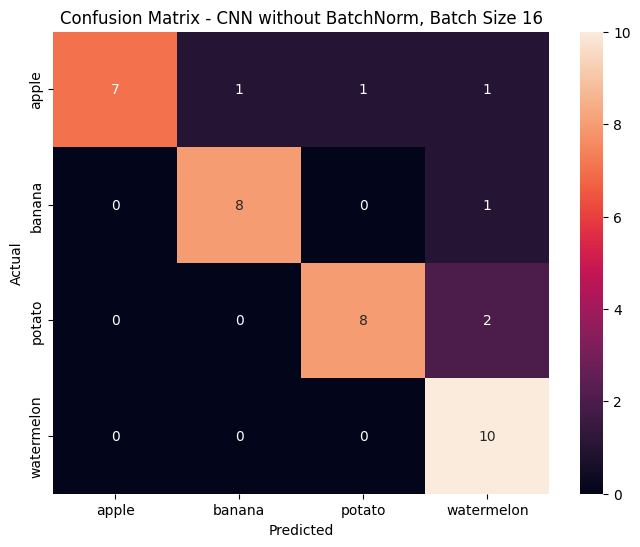

In [13]:
# CONFUSION MATRIX

predictions = best_model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

print("\nClassification Report:")
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}, Batch Size {best_batch_size}")
plt.show()

# Short Interpretation

This final section prints a short summary of the main results. I use this as a starting point for writing the A7 results discussion in the report. The most important points are whether Batch Normalization improved performance and whether the smallest batch size affected BN stability.

In [14]:
# SHORT INTERPRETATION

bn_results = results_df[results_df["Model"] == "CNN with BatchNorm"]
no_bn_results = results_df[results_df["Model"] == "CNN without BatchNorm"]

best_bn = bn_results.sort_values(by="Validation Accuracy", ascending=False).iloc[0]
best_no_bn = no_bn_results.sort_values(by="Validation Accuracy", ascending=False).iloc[0]

print("\nInterpretation Summary:")

print(
    f"The best BatchNorm model achieved validation accuracy of "
    f"{best_bn['Validation Accuracy']:.4f} with batch size {int(best_bn['Batch Size'])}."
)

print(
    f"The best non-BatchNorm model achieved validation accuracy of "
    f"{best_no_bn['Validation Accuracy']:.4f} with batch size {int(best_no_bn['Batch Size'])}."
)

if best_bn["Validation Accuracy"] > best_no_bn["Validation Accuracy"]:
    print("Batch Normalization improved validation performance in this experiment.")
else:
    print("Batch Normalization did not improve final validation accuracy, but training stability and convergence should still be discussed.")

small_batch_bn = bn_results[bn_results["Batch Size"] == 8].iloc[0]

print(
    f"With batch size 8, BatchNorm achieved validation accuracy of "
    f"{small_batch_bn['Validation Accuracy']:.4f}. This can be discussed because BN may become less stable with very small batches."
)

# =========================
# SAVE BEST MODEL
# =========================

best_model.save("best_batchnorm_project_model.h5")
print("\nBest model saved.")


Interpretation Summary:
The best BatchNorm model achieved validation accuracy of 0.8718 with batch size 8.
The best non-BatchNorm model achieved validation accuracy of 0.9487 with batch size 16.
Batch Normalization did not improve final validation accuracy, but training stability and convergence should still be discussed.
With batch size 8, BatchNorm achieved validation accuracy of 0.8718. This can be discussed because BN may become less stable with very small batches.

Best model saved.
